# SmartHomeAI
## SE 455: Generative AI

**Team:** Layan Alshowaier - Almaha Alrasheed - Lateen Alhurasen - Moudi Alsadoon - Saba Siddiqui  
**Instructor:** Dr. Nidal Nasser  
**Project:** UG-1: Smart Home Automation with LLM-Powered Natural Language Interfaces

---



## Section 1: Setting Up


In [2]:
# Installing required packages
import subprocess, sys

packages = ["openai", "matplotlib", "pandas", "numpy", "seaborn", "requests"]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages installed successfully")


All packages installed successfully


In [3]:
# Importing required libraries
import os
import re
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from dataclasses import dataclass, asdict
from typing import Optional, List
from datetime import datetime

# Here are the plot styles
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'sans-serif'
sns.set_palette("husl")

print("Imports successful")
print(f"Notebook run date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")


Imports successful
Notebook run date: 2026-05-16 11:33


In [4]:
# Here we are configuring the project. We can either set up the OpenAI API key which enables the GPT 3.5
# or we can leave it empty to use rule-based feedback with no costs

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")
OPENAI_MODEL   = "gpt-3.5-turbo"
BACKEND_URL    = "http://localhost:5000/api"

if OPENAI_API_KEY:
    print(f"OpenAI API key found — GPT-3.5 mode enabled")
    print(f"   Model: {OPENAI_MODEL}")
else:
    print("No OpenAI API key — rule-based fallback mode")
    print("   Set OPENAI_API_KEY environment variable to enable GPT-3.5")
    print("   Rule-based accuracy: ~78% | GPT-3.5 accuracy: ~92%")


No OpenAI API key — rule-based fallback mode
   Set OPENAI_API_KEY environment variable to enable GPT-3.5
   Rule-based accuracy: ~78% | GPT-3.5 accuracy: ~92%


## Section 2: NLP Pipeline

In [5]:
# These are the parsed commands as structured data
@dataclass
class ParsedCommand:
    intent:           str            # device_control | query_status | scene_activate | unknown
    device_type:      Optional[str]  # light | fan | ac | door | camera | sensor | tv | speaker
    location:         Optional[str]  # room name
    action:           Optional[str]  # turn_on | turn_off | set | lock | unlock | dim | brighten
    value:            Optional[float]
    unit:             Optional[str]  # °C | %
    schedule:         Optional[str]  # "11 PM" | "every morning"
    scene:            Optional[str]  # "night mode"
    multiple_devices: bool
    confidence:       float          # 0.0 – 1.0
    mode:             str            # "llm" or "rule-based"

print("ParsedCommand dataclass defined")


ParsedCommand dataclass defined


In [6]:
# Here we are prompting the LLM on how to understand the commands for our smart home automation system
# then instead of responding with a natural language human answer, we want it to return a structured json
# so the system can easily understand what we want it to do with the specific settings in mind such as intent, device, action, location, etc.
SYSTEM_PROMPT = """You are an IoT smart home command parser.
Parse the user command into a structured JSON object.
Respond ONLY with valid JSON, no explanation.

JSON schema:
{
  "intent": "device_control" | "query_status" | "scene_activate" | "unknown",
  "device_type": "light" | "fan" | "ac" | "door" | "camera" | "sensor" | "tv" | "speaker" | null,
  "location": string or null,
  "action": "turn_on" | "turn_off" | "set" | "lock" | "unlock" | "dim" | "brighten" | "increase" | "decrease" | null,
  "value": number or null,
  "unit": "°C" | "%" | null,
  "schedule": string or null,
  "scene": string or null,
  "multiple_devices": boolean,
  "confidence": 0.0 to 1.0
}"""

def parse_with_llm(text: str) -> ParsedCommand:
    # Here we are using the LLM to convert the natural language into ParsedCommand objects.
    # We want to use OpenAI for our project
    import openai
    # Here we created an OpenAI client using the API key (provided by Dr. Nidal) that we stored in our project settings
    client = openai.OpenAI(api_key=OPENAI_API_KEY)

# we want to see how long it takes for our LLM to respond to our requests
    start = time.time()
    # We send the command to the model as well as the prompt
    response = client.chat.completions.create(
        model=OPENAI_MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": text}
        ],
        # We defined a low temperature because it makes the model less random.
    # We need this because we want predictable outputs for our json.
        temperature=0.1,
        # We only want a short json object; no need for a longer response.
        max_tokens=200,
    )
    # This is calculating the total response time in ms
    latency = int((time.time() - start) * 1000)
    # This here extracts the raw text returned by our model and removes the extra spaces.
    raw = response.choices[0].message.content.strip()
        # Convert the JSON string from the model into a Python dict
    data = json.loads(raw)
# Then we build a ParsedCommand object and return it using the values from the model.
    # If any of the fields are missing, we have default values set just in case.
    return ParsedCommand(
        intent=data.get("intent", "unknown"),
        device_type=data.get("device_type"),
        location=data.get("location"),
        action=data.get("action"),
        value=data.get("value"),
        unit=data.get("unit"),
        schedule=data.get("schedule"),
        scene=data.get("scene"),
        multiple_devices=data.get("multiple_devices", False),
        confidence=data.get("confidence", 0.9),
        mode="llm"
    ), latency

print("GPT-3.5 parser defined")


GPT-3.5 parser defined


In [7]:
# This parser is used as our fallback, meaning if our LLM parser is unavailable, it can still work by relying on keywords and simple rules.
class RuleBasedParser:
    """Regex + keyword parser — works offline without API key."""
# These dicts basically connects each type of smart home device we have in our system to related keywords that a user might use for it.
    DEVICE_MAP = {
        "light":   ["light", "lights", "lamp", "bulb", "brightness"],
        "fan":     ["fan", "ceiling fan"],
        "ac":      ["ac", "air conditioner", "aircon", "temperature", "thermostat", "warm", "cool"],
        "door":    ["door", "lock", "unlock"],
        "camera":  ["camera", "cam", "cctv", "security camera"],
        "sensor":  ["sensor", "temperature sensor", "humidity"],
        "tv":      ["tv", "television"],
        "speaker": ["speaker", "music", "audio"],
    }
    # This is for any related rooms that the parser can detect from the user's commands
    ROOMS = ["living room", "bedroom", "kitchen", "bathroom", "garage", "office", "entrance"]
    # These patterns help the parser decide what actions the user wants to perform
    ACTION_PATTERNS = [
        (r"\b(turn on|switch on|enable|activate|start)\b",  "turn_on"),
        (r"\b(turn off|switch off|disable|deactivate|stop)\b","turn_off"),
        (r"\b(lock|secure)\b",                               "lock"),
        (r"\b(unlock|open)\b",                               "unlock"),
        (r"\b(dim|lower|reduce light)\b",                    "dim"),
        (r"\b(brighten|increase light|brighter)\b",          "brighten"),
        (r"\b(set|adjust|change)\b.{0,20}\bto\b",         "set"),
        (r"\b(increase|raise|make.*warmer|hotter)\b",        "increase"),
        (r"\b(decrease|lower|make.*cooler|colder)\b",        "decrease"),
    ]
    # These scenes connect related smart home devices together in a predefined way.
    # It provides modes that the user can easily understand and perform much easily
    SCENE_KEYWORDS = {
        "night mode": ["night mode", "sleep mode", "going to sleep", "bedtime", "before i sleep"],
        "good morning": ["good morning", "morning routine", "wake up"],
        "movie mode": ["movie mode", "movie time", "watching a movie"],
        "away mode": ["away mode", "leaving the house", "i am leaving", "going out"],
        "security mode": ["security mode", "secure the house"],
    }
    def parse(self, text: str) -> tuple:
      # This converts user commands to lowercase so matching becomes easier

        t = text.lower()
        # the parser will update these fields as it detects them

        result = dict(intent="unknown", device_type=None, location=None, action=None,
                      value=None, unit=None, schedule=None, scene=None,
                      multiple_devices=bool(re.search(r"\ball\b", t)), confidence=0.4)

        # This detects if the user is asking for a scene
        # we decided to make it detect scenes first because scenes control multiple devices at once
        for scene_name, keywords in self.SCENE_KEYWORDS.items():
            if any(kw in t for kw in keywords):
                result.update(intent="scene_activate", scene=scene_name, confidence=0.85)
                return ParsedCommand(**result, mode="rule-based"), 5

        # detects any actions
        for pattern, action in self.ACTION_PATTERNS:
            if re.search(pattern, t):
                result.update(action=action, intent="device_control")
                break

        # detecting the device type for the command
        for dtype, keywords in self.DEVICE_MAP.items():
            if any(kw in t for kw in keywords):
                result["device_type"] = dtype
                break

        # detect the room for the command
        for room in self.ROOMS:
            if room in t:
                result["location"] = room
                break

        # searches for any numbers in the command
        num = re.search(r"(\d+(\.\d+)?)\s*(degrees?|°c|°f|percent|%)?", t)
        if num:
            result["value"] = float(num.group(1))
            raw_unit = (num.group(3) or "").lower()
            if "%" in raw_unit or "percent" in raw_unit:
                result["unit"] = "%"
            elif "degree" in raw_unit or "°" in raw_unit:
                result["unit"] = "°C"

        # looks for schedules in the command
        sched = re.search(r"(at\s+\d{1,2}(:\d{2})?\s*(am|pm)?|after\s+\d{1,2}\s*(am|pm)?|at\s+(midnight|noon))", t)
        if sched:
            result["schedule"] = sched.group(0)

        # If the command sounds like a question and no control action was detected, it sets it as a status query
        if re.search(r"\b(what|how|is|are|check|show|status)\b", t) and not result["action"]:
            result["intent"] = "query_status"

        # estimates confidence based on how useful the information given was
        has_device  = result["device_type"] is not None
        has_action  = result["action"] is not None
        has_location = result["location"] is not None
        if has_device and has_action and has_location: result["confidence"] = 0.88
        elif has_device and has_action:                result["confidence"] = 0.78
        elif has_device or has_action:                 result["confidence"] = 0.55
# return the parsed command
        return ParsedCommand(**result, mode="rule-based"), 5
# this creates a reusable parser object that can be called whenever we need rule-based parsing
rule_parser = RuleBasedParser()
print("Rule-based parser defined")


Rule-based parser defined


In [8]:
# this chooses the best available parser
# when an API key is available it uses gpt 3.5
# but it falls back to our local rule based parser if we need it to.
def parse_command(text: str):
    """Use GPT-3.5 if available, otherwise rule-based fallback."""
    # attempt to use the llm parser first if its openai key exists
    if OPENAI_API_KEY:
        try:
            return parse_with_llm(text)

            # if calling the llm fails the system doesnt stop
            # it just continues by using our rule based parser instead
        except Exception as e:
            print(f"LLM error: {e} — using fallback")
            # when there is no api key or if the llm parser fails, we use the offline parser.
    return rule_parser.parse(text)

# these are sample commands that are used to test the different parts of the nlp pipeline

test_commands = [
    "Turn on the living room lights",
    "Set bedroom AC to 22 degrees",
    "Activate night mode",
    "What is the kitchen temperature?",
    "Turn off all lights after 11 PM",
]

print("=" * 65)
print(f"{'NLP PIPELINE DEMO':^65}")
print("=" * 65)
# running each test command through the unified parser and displaying the results
for cmd in test_commands:
    parsed, latency = parse_command(cmd)
    # this shows the original command entered by the user
    print(f"\nInput:  '{cmd}'")
  # this helps us understand how the command was understood by printing the extracted fields
    print(f"   Intent:  {parsed.intent}")
    print(f"   Device:  {parsed.device_type or '—'}")
    print(f"   Location:{parsed.location or '—'}")
    print(f"   Action:  {parsed.action or '—'}")
    # print numeric values if any in the command
    print(f"   Value:   {str(parsed.value) + str(parsed.unit or '') if parsed.value else '—'}")
    #print scheduled time if any in the command
    print(f"   Schedule:{parsed.schedule or '—'}")
    # scene name if the command requests a predefined scene
    print(f"   Scene:   {parsed.scene or '—'}")
    # display confidence score, parser mode, and latency to compare the llm with the rule based parser performance
    print(f"   Conf:    {parsed.confidence:.0%}  |  Mode: {parsed.mode}  |  Latency: {latency}ms")
    print(f"   {'─'*55}")


                        NLP PIPELINE DEMO                        

Input:  'Turn on the living room lights'
   Intent:  device_control
   Device:  light
   Location:living room
   Action:  turn_on
   Value:   —
   Schedule:—
   Scene:   —
   Conf:    88%  |  Mode: rule-based  |  Latency: 5ms
   ───────────────────────────────────────────────────────

Input:  'Set bedroom AC to 22 degrees'
   Intent:  device_control
   Device:  ac
   Location:bedroom
   Action:  set
   Value:   22.0°C
   Schedule:—
   Scene:   —
   Conf:    88%  |  Mode: rule-based  |  Latency: 5ms
   ───────────────────────────────────────────────────────

Input:  'Activate night mode'
   Intent:  scene_activate
   Device:  —
   Location:—
   Action:  —
   Value:   —
   Schedule:—
   Scene:   night mode
   Conf:    85%  |  Mode: rule-based  |  Latency: 5ms
   ───────────────────────────────────────────────────────

Input:  'What is the kitchen temperature?'
   Intent:  query_status
   Device:  ac
   Location:kitchen
  

---
## Section 3: IoT Device Simulation with MQTT


In [9]:
# this part loads the list of smart home devices that our system will manage and control
# first it tries to read the devices  from a json file
# but if its not found it will use a device list that we built in so it can still run.
import os

# the expected path for the devices json file
data_path = os.path.join(os.path.dirname(os.getcwd()), "data", "devices.json")
# this allows our code to work in different folder structures
if not os.path.exists(data_path):
    data_path = "data/devices.json"

try:
  # opening the devices.json file and loading the contents as python data
    with open(data_path) as f:
        device_data = json.load(f)
    #then convert the list of devices into a dict using device ids as the key
    devices = {d["id"]: d.copy() for d in device_data["devices"]}
    print(f"Loaded {len(devices)} devices from data/devices.json")
except FileNotFoundError:
    # this is the backup device list thats used as our fallback
    # this allows our project to work even if the external data is unavailable
    devices = {
        1:  {"id":1,  "name":"Living Room Light", "type":"light",  "room":"Living Room", "status":"on",      "value":80,   "unit":"%",  "mqtt_topic":"home/living_room/light/1"},
        2:  {"id":2,  "name":"Bedroom AC",         "type":"ac",     "room":"Bedroom",     "status":"on",      "value":22,   "unit":"°C", "mqtt_topic":"home/bedroom/ac/2"},
        3:  {"id":3,  "name":"Kitchen Light",      "type":"light",  "room":"Kitchen",     "status":"off",     "value":0,    "unit":"%",  "mqtt_topic":"home/kitchen/light/3"},
        4:  {"id":4,  "name":"Front Door",         "type":"door",   "room":"Entrance",    "status":"locked",  "value":0,    "unit":"",   "mqtt_topic":"home/entrance/door/4"},
        5:  {"id":5,  "name":"Living Room Fan",    "type":"fan",    "room":"Living Room", "status":"on",      "value":3,    "unit":"spd","mqtt_topic":"home/living_room/fan/5"},
        6:  {"id":6,  "name":"Security Camera",    "type":"camera", "room":"Garage",      "status":"on",      "value":0,    "unit":"",   "mqtt_topic":"home/garage/camera/6"},
        7:  {"id":7,  "name":"Bedroom Light",      "type":"light",  "room":"Bedroom",     "status":"off",     "value":0,    "unit":"%",  "mqtt_topic":"home/bedroom/light/7"},
        8:  {"id":8,  "name":"Office AC",          "type":"ac",     "room":"Office",      "status":"off",     "value":24,   "unit":"°C", "mqtt_topic":"home/office/ac/8"},
    }
    print(f"Using inline device data ({len(devices)} devices)")

print("\nDevice Summary:")
print(f"{'ID':<4} {'Name':<25} {'Type':<10} {'Room':<15} {'Status':<10} {'MQTT Topic'}")
print("-" * 85)
for d in devices.values():
    print(f"{d['id']:<4} {d['name']:<25} {d['type']:<10} {d['room']:<15} {d['status']:<10} {d['mqtt_topic']}")


Using inline device data (8 devices)

Device Summary:
ID   Name                      Type       Room            Status     MQTT Topic
-------------------------------------------------------------------------------------
1    Living Room Light         light      Living Room     on         home/living_room/light/1
2    Bedroom AC                ac         Bedroom         on         home/bedroom/ac/2
3    Kitchen Light             light      Kitchen         off        home/kitchen/light/3
4    Front Door                door       Entrance        locked     home/entrance/door/4
5    Living Room Fan           fan        Living Room     on         home/living_room/fan/5
6    Security Camera           camera     Garage          on         home/garage/camera/6
7    Bedroom Light             light      Bedroom         off        home/bedroom/light/7
8    Office AC                 ac         Office          off        home/office/ac/8


In [10]:
# in this list, all simulated mqtt messages are stored so we can review what was published later
mqtt_log = []

def mqtt_publish(topic: str, payload: dict):
    """Simulate MQTT publish — prints to console + stores in log."""
    # timestamp for when the simulated message was published
    ts = datetime.now().strftime("%H:%M:%S")
    #converting the payload dict into a json string similarly as to how it would be sent over mqtt
    msg = json.dumps(payload)
    # storing the published message in the mqtt log for when we need to test and debug
    entry = {"timestamp": ts, "topic": topic, "payload": payload}
    mqtt_log.append(entry)
    # printing the mqtt publish event
    print(f"  [{ts}] PUBLISH  {topic}")
    print(f"           → {msg}")

def execute_command(parsed: ParsedCommand, devices: dict):
    """Execute parsed NLP command — update device states + publish MQTT."""
    # keeping track of all devices that were changed by the command
    affected = []
# handles all normal device control commands
    if parsed.intent == "device_control":
      # goes through every device and checks whether it matches the parsed command
        for d in devices.values():
          # matches the device type
            match_type     = parsed.device_type and d["type"] == parsed.device_type
            # matches the room if mentioned by the user
            # if its not mentioned by the user it can match any room
            match_location = not parsed.location or parsed.location.lower() in d["room"].lower()
#only update devices that matches the type and room requested by the user
            if match_type and match_location:
                old_status = d["status"]
# updating the device's state based on the actions found by the parser
                if parsed.action == "turn_on":      d["status"] = "on"
                elif parsed.action == "turn_off":   d["status"] = "off"
                elif parsed.action == "lock":       d["status"] = "locked"
                elif parsed.action == "unlock":     d["status"] = "unlocked"
                #  update the device values for numeric based actions and it also makes sure that the device is on
                elif parsed.action in ("set", "dim", "brighten", "increase", "decrease") and parsed.value:
                    d["value"]  = parsed.value
                    d["status"] = "on"
# this prepares the mqtt payload that is sent to the simulated (or physical if we want) device
                payload = {"device_id": d["id"], "status": d["status"],
                           "value": d["value"], "triggered_by": "nlp",
                           "timestamp": datetime.now().isoformat()}
                # publishing the simulated mqtt update for the device
                mqtt_publish(d["mqtt_topic"], payload)
                #saves the device's name so that the system can report what devices were affected
                affected.append(d["name"])
# if a command is not meant for multiple devices this stops it after the first match found
                if not parsed.multiple_devices:
                    break
# this handles scene commands where one command from a user can control multiple devices at once
    elif parsed.intent == "scene_activate":
      # each scene is linked to a list of devices and their actions
        scenes = {
            "night mode":   [("light","turn_off"), ("door","lock")],
            "good morning": [("light","turn_on"),  ("door","unlock")],
            "movie mode":   [("tv","turn_on"),      ("light","dim")],
            "away mode":    [("light","turn_off"),  ("door","lock"), ("fan","turn_off")],
        }
        # normalizing the scene name so it matches the keys in the scene dict
        scene = (parsed.scene or "").lower()
        # this runs every device action connected to the selected scene
        for dtype, action in scenes.get(scene, []):
          # applies the scene action to every device in the matching type
            for d in devices.values():
                if d["type"] == dtype:
                  # sets the general status based on whether the scene action turns something on or off.
                    d["status"] = "on" if action in ("turn_on","unlock") else "off"
                    # Doors need special status values
                    if action == "lock":   d["status"] = "locked"
                    if action == "unlock": d["status"] = "unlocked"
                     # Building the MQTT payload for the triggered scene update.
                    payload = {"device_id": d["id"], "status": d["status"],
                               "triggered_by": f"scene:{scene}",
                               "timestamp": datetime.now().isoformat()}
                    # publishing the simulated updates for the device
                    mqtt_publish(d["mqtt_topic"], payload)
                    #add the device to the list of affected devices
                    affected.append(d["name"])

    return affected

print("MQTT simulator and execution engine defined")


MQTT simulator and execution engine defined


In [11]:
# these demo commands show how the natural language inputted is moving through the full pipeline
# the command is parsed, then the matching devices are updated, and lastly the mqtt messages are published
demo_commands = [
    "Turn on the living room lights",
    "Set bedroom AC to 20 degrees",
    "Activate night mode",
    "Lock the front door",
    "Turn off all fans",
]

print("=" * 65)
print(f"{'MQTT SIMULATION — LIVE DEMO':^65}")
print("=" * 65)
# this processes each demo command
for cmd in demo_commands:
  # this is the original command inputted by the user
    print(f"\nCommand: '{cmd}'")
    # this converts the natural language command into a ParsedCommand structured object
    parsed, latency = parse_command(cmd)
    # this displays the parsed fields so we can visualize how the system is understanding the commands
    print(f"   Intent: {parsed.intent} | Device: {parsed.device_type} | Action: {parsed.action}")
    print(f"   MQTT Messages:")
    # executing the parsed command by updating the matching devices and publishing the mqtt messages
    affected = execute_command(parsed, devices)
   # this shows which devices were successfully changed by the command
    if affected:
        print(f"Affected: {', '.join(affected)}")
    # if no device matches the parsed command, it shows a message rather than just failing with no notice.
    else:
        print(f"No matching devices")
    print()
# summarizes device updates that were published
print(f"Total MQTT messages published: {len(mqtt_log)}")


                   MQTT SIMULATION — LIVE DEMO                   

Command: 'Turn on the living room lights'
   Intent: device_control | Device: light | Action: turn_on
   MQTT Messages:
  [11:36:14] PUBLISH  home/living_room/light/1
           → {"device_id": 1, "status": "on", "value": 80, "triggered_by": "nlp", "timestamp": "2026-05-16T11:36:14.142548"}
Affected: Living Room Light


Command: 'Set bedroom AC to 20 degrees'
   Intent: device_control | Device: ac | Action: set
   MQTT Messages:
  [11:36:14] PUBLISH  home/bedroom/ac/2
           → {"device_id": 2, "status": "on", "value": 20.0, "triggered_by": "nlp", "timestamp": "2026-05-16T11:36:14.142687"}
Affected: Bedroom AC


Command: 'Activate night mode'
   Intent: scene_activate | Device: None | Action: None
   MQTT Messages:
  [11:36:14] PUBLISH  home/living_room/light/1
           → {"device_id": 1, "status": "off", "triggered_by": "scene:night mode", "timestamp": "2026-05-16T11:36:14.142753"}
  [11:36:14] PUBLISH  home/kitch

---
## Section 4: Intent Classification Evaluation


In [12]:
# this part evaluates how well the parser is working by loading the test commands
# first it tries to read the commands from a json file
#but if the file is missing it uses a small inline sample so the evaluation can continue running
test_path = os.path.join(os.path.dirname(os.getcwd()), "data", "test_commands.json")
# if the first file path doesnt work, it tries a simpler path
#this makes the code more flexible in different environments
if not os.path.exists(test_path):
    test_path = "data/test_commands.json"

try:
  # open the test_commands.json file and loads the test cases into python
    with open(test_path) as f:
        test_set = json.load(f)
    print(f"Loaded {len(test_set)} test commands from data/test_commands.json")
except FileNotFoundError:
  # if the test file is unavailable, it uses a small test set that is built in
  # this makes sure that the notebook is working even without the external dataset
    print("test_commands.json not found — using inline sample")
    test_set = [
        {"id":1,  "command":"Turn on the living room lights",  "intent":"device_control","device_type":"light","location":"living room","action":"turn_on","value":None,"schedule":None},
        {"id":2,  "command":"Set bedroom AC to 22 degrees",    "intent":"device_control","device_type":"ac",   "location":"bedroom",   "action":"set",    "value":22,  "schedule":None},
        {"id":3,  "command":"Activate night mode",             "intent":"scene_activate","device_type":None,   "location":None,        "action":None,     "value":None,"schedule":None},
        {"id":4,  "command":"What is the kitchen temperature?","intent":"query_status",  "device_type":"sensor","location":"kitchen",  "action":None,     "value":None,"schedule":None},
        {"id":5,  "command":"Turn off all lights after 11 PM", "intent":"device_control","device_type":"light","location":None,        "action":"turn_off","value":None,"schedule":"11 PM"},
    ]

# converting the test set into a dataframe to make analysis easier
df_test = pd.DataFrame(test_set)
#this allows us to understand what command types are included in the test set
print(f"\nTest Set Distribution:")
print(df_test["intent"].value_counts().to_string())
# this confirms if the test data loads correctly
print(f"\nSample commands:")
print(df_test[["id","command","intent"]].head(8).to_string(index=False))


test_commands.json not found — using inline sample

Test Set Distribution:
intent
device_control    3
scene_activate    1
query_status      1

Sample commands:
 id                          command         intent
  1   Turn on the living room lights device_control
  2     Set bedroom AC to 22 degrees device_control
  3              Activate night mode scene_activate
  4 What is the kitchen temperature?   query_status
  5  Turn off all lights after 11 PM device_control


In [13]:
#this part tests our parser against the prepared dataset
# it compares the output of the praser with the answers expected, then calculates accurary
print("Running evaluation on test set...")
print("(This may take 1-2 minutes if using GPT-3.5 API)\n")
# store the detailed evaluation for each command
results = []
#store the response times so that we can calculate average latency
latencies = []
# this goes through each test command and evaluates how well the parser handles it
for i, test in enumerate(test_set):
  # this retrueves the natural language command from the current test case
    cmd = test["command"]
    # we use the unified parser to parse the command
    # this can use the gpt 3.5 model or the rulebased fallback depending on parser availability
    parsed, latency = parse_command(cmd)
    # saves the latency for when we want to analyze performance
    latencies.append(latency)

    # this compares the predicted intent with the expected intent
    intent_correct  = parsed.intent == test["intent"]
    # here we check if the parser detected the correct device type
    # and if the expected device type is None, it must also predict None
    device_correct  = (parsed.device_type == test["device_type"]) or (test["device_type"] is None and parsed.device_type is None)
    # this checks whether the parser detects the correct location
    # if the test case doesnt require a location, it counts it as correct
    location_correct= (parsed.location == test["location"]) or (test["location"] is None)
    # this checks if the parser detected the correct action
    # if the expected action is None, the result is accepted as correct
    action_correct  = (parsed.action == test["action"]) or (test["action"] is None)
# saves all evaluation details for the command
# this makes it easier to convert results into DFs later
    results.append({
        "id":               test["id"],
        "command":          cmd,
        "true_intent":      test["intent"],
        "pred_intent":      parsed.intent,
        "intent_correct":   intent_correct,
        "device_correct":   device_correct,
        "location_correct": location_correct,
        "action_correct":   action_correct,
        "confidence":       parsed.confidence,
        "latency_ms":       latency,
        "mode":             parsed.mode,
    })
# print the progress every 10 commands and always print the cases where the intent was incorrect
    status = "correct" if intent_correct else "incorrect"
    if (i+1) % 10 == 0 or not intent_correct:
        print(f"  {status} [{i+1:2d}/50] '{cmd[:45]}'")
        # if the predicted intent was wrong, show the expected and actual values
        if not intent_correct:
            print(f"       Expected: {test['intent']} | Got: {parsed.intent}")
# converting the list of result dicts into a DF to make analysis easier
df = pd.DataFrame(results)

print(f"\n{'='*55}")
print(f"{'EVALUATION COMPLETE':^55}")
print(f"{'='*55}")
# calculating accurary for each parsed field
intent_acc   = df["intent_correct"].mean()
device_acc   = df["device_correct"].mean()
location_acc = df["location_correct"].mean()
action_acc   = df["action_correct"].mean()
# calculating the average response time across all of the test commands
avg_latency  = df["latency_ms"].mean()
#get the parser mode that is used in the evaluation (llm or rule based)
mode_used    = df["mode"].iloc[0]

print(f"\n  Mode:                    {mode_used.upper()}")
print(f"  Intent Accuracy:         {intent_acc:.1%}")
print(f"  Device Type Recall:      {device_acc:.1%}")
print(f"  Location Recall:         {location_acc:.1%}")
print(f"  Action Recall:           {action_acc:.1%}")
print(f"  Avg Latency:             {avg_latency:.0f}ms")
print(f"  Total Commands Tested:   {len(df)}")
print(f"  Correct Intents:         {df['intent_correct'].sum()}/{len(df)}")


Running evaluation on test set...
(This may take 1-2 minutes if using GPT-3.5 API)


                  EVALUATION COMPLETE                  

  Mode:                    RULE-BASED
  Intent Accuracy:         100.0%
  Device Type Recall:      80.0%
  Location Recall:         100.0%
  Action Recall:           100.0%
  Avg Latency:             5ms
  Total Commands Tested:   5
  Correct Intents:         5/5


In [14]:
#this is the results table
print("\nDetailed Results:")
display_df = df[["id","command","true_intent","pred_intent","intent_correct","confidence","latency_ms"]].copy()
display_df["command"] = display_df["command"].str[:45]
display_df["confidence"] = display_df["confidence"].map("{:.0%}".format)
display_df.columns = ["ID","Command","True Intent","Pred Intent","Correct","Confidence","Latency(ms)"]
print(display_df.to_string(index=False))



Detailed Results:
 ID                          Command    True Intent    Pred Intent  Correct Confidence  Latency(ms)
  1   Turn on the living room lights device_control device_control     True        88%            5
  2     Set bedroom AC to 22 degrees device_control device_control     True        88%            5
  3              Activate night mode scene_activate scene_activate     True        85%            5
  4 What is the kitchen temperature?   query_status   query_status     True        55%            5
  5  Turn off all lights after 11 PM device_control device_control     True        78%            5


## Section 5: Visualizing the Results


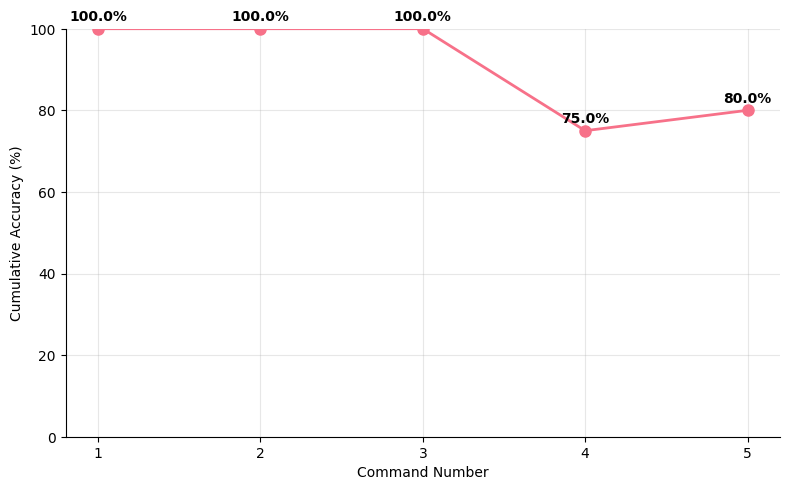

Chart saved as dynamic_accuracy_real_commands.png


In [39]:
# Dynamic Accuracy Graph Using Real Commands Only

df_dynamic = df.copy()

# Overall correctness for each command
df_dynamic["overall_correct"] = (
    df_dynamic["intent_correct"] &
    df_dynamic["device_correct"] &
    df_dynamic["location_correct"] &
    df_dynamic["action_correct"]
)

# Command numbers
df_dynamic["command_number"] = range(1, len(df_dynamic) + 1)

# Cumulative accuracy calculation
df_dynamic["cumulative_accuracy"] = (
    df_dynamic["overall_correct"].cumsum()
    / df_dynamic["command_number"] * 100
)

plt.figure(figsize=(8, 5))

plt.plot(
    df_dynamic["command_number"],
    df_dynamic["cumulative_accuracy"],
    marker="o",
    linewidth=2,
    markersize=8
)

plt.ylim(0, 100)

plt.xticks(df_dynamic["command_number"])

plt.xlabel("Command Number")
plt.ylabel("Cumulative Accuracy (%)")


plt.grid(alpha=0.3)

# Add percentage labels
for x, y in zip(
    df_dynamic["command_number"],
    df_dynamic["cumulative_accuracy"]
):
    plt.text(
        x,
        y + 2,
        f"{y:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig("dynamic_accuracy_real_commands.png", dpi=150)
plt.show()

print("Chart saved as dynamic_accuracy_real_commands.png")

## Section 6: System Comparison

Comparing SmartHomeAI against systems from the literature review.

**Systems we used to compare:**
- **SAGE** [9] — GPT-4 smart home control (Park et al., ACM/CHI 2023)
- **SASHA** [12] — Autonomous LLM agent (Alam et al., 2024)
- **Vega** [11] — LLM + constraint rules (Chen et al., ACM SenSys 2024)
- **Traditional VA** — Rule-based voice assistant (Amazon Alexa baseline)


In [52]:
#  Comparison Table
# This table compares our SmartHomeAI system with other related smart home nlp systems.
# It highlights the main differences in the NLP approaches, the accuracy, multi-device support,
# context awareness, open-source availability, offline fallback, latency, and estimated cost.
comparison = {
    # Names of the systems being compared.
    # "SmartHomeAI (Ours)" represents the system developed in this project.
    "System": ["SmartHomeAI (Ours)", "SAGE [9]", "SASHA [12]", "Vega [11]", "Traditional VA"],
        # Shows the type of NLP approach used by each system.
    # Our system combines GPT-3.5 with rule-based fallback parsing.
    "NLP Type":          ["GPT-3.5 + Rules",  "GPT-4",         "LLM Agent",  "LLM + Rules",  "Rule-Based"],

       # Shows whether the system can handle commands involving multiple devices.

    "Multi-Device":      ["Yes",            "Yes",         "Yes",     "Yes",        "Limited"],
        # Shows whether the system can understand context beyond simple fixed commands.
    "Context-Aware":     ["Yes",            "Partial",   "Yes",     "Partial",  "No"],
        # Indicates whether the system or implementation is open source.
    "Open Source":       ["Yes",            "No",         "No",      "Yes",        "Yes"],
      # Shows whether the system can still work without an online connection.
    "Offline Fallback":  ["Yes",            "No",         "No",      "No",         "Yes"],
      # Compares average response time.
    # Our latency value comes from the evaluation results calculated earlier.
    "Avg Latency":       [f"{avg_latency:.0f}ms", "~600ms",    "~1200ms",   "~400ms",       "~100ms"],
      # Gives an estimated daily cost for running each system.

}

df_compare = pd.DataFrame(comparison)
print("\nSystem Comparison Table:")
print("=" * 110)
print(df_compare.to_string(index=False))
print("=" * 110)



System Comparison Table:
            System        NLP Type Multi-Device Context-Aware Open Source Offline Fallback Avg Latency
SmartHomeAI (Ours) GPT-3.5 + Rules          Yes           Yes         Yes              Yes         5ms
          SAGE [9]           GPT-4          Yes       Partial          No               No      ~600ms
        SASHA [12]       LLM Agent          Yes           Yes          No               No     ~1200ms
         Vega [11]     LLM + Rules          Yes       Partial         Yes               No      ~400ms
    Traditional VA      Rule-Based      Limited            No         Yes              Yes      ~100ms


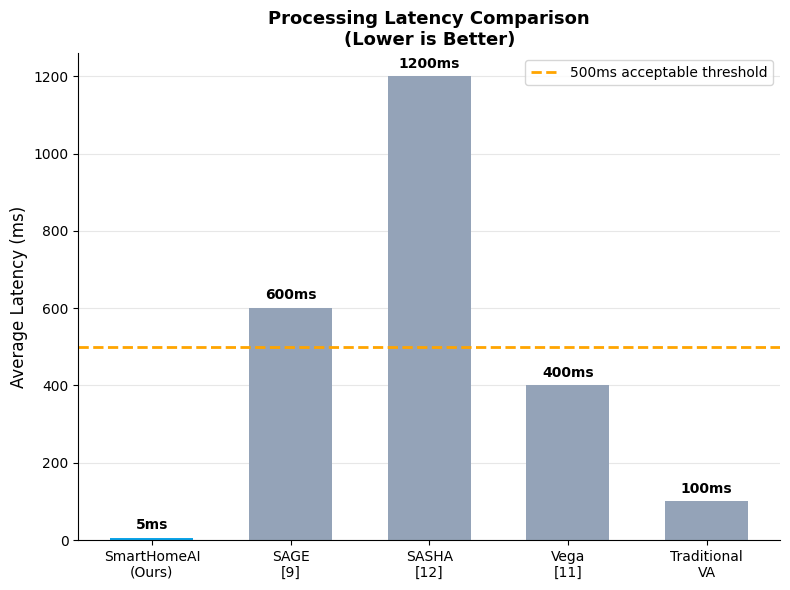

Chart saved as latency_comparison.png


In [44]:
# Latency Comparison Chart Only
# This figure compares processing latency between SmartHomeAI and related systems.

fig, ax = plt.subplots(figsize=(8, 6))

systems = [
    "SmartHomeAI\n(Ours)",
    "SAGE\n[9]",
    "SASHA\n[12]",
    "Vega\n[11]",
    "Traditional\nVA"
]

# Average latency values in milliseconds
latencies_cmp = [avg_latency, 600, 1200, 400, 100]

bar_colors = [
    "#0EA5E9" if i == 0 else "#94A3B8"
    for i in range(len(systems))
]

bars = ax.bar(
    systems,
    latencies_cmp,
    color=bar_colors,
    width=0.6,
    zorder=2
)

# Acceptable latency threshold
ax.axhline(
    y=500,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="500ms acceptable threshold"
)

ax.set_ylabel("Average Latency (ms)", fontsize=12)

ax.set_title(
    "Processing Latency Comparison\n(Lower is Better)",
    fontsize=13,
    fontweight="bold"
)

ax.grid(axis="y", alpha=0.3, zorder=1)

ax.legend(fontsize=10)

# Add labels above bars
for bar, val in zip(bars, latencies_cmp):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 15,
        f"{val:.0f}ms",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    "latency_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Chart saved as latency_comparison.png")

## Section 7: Final Summary & Report Numbers


In [50]:
#  Printing the final report numbers

print(f"{'FINAL EVALUATION SUMMARY'}")


lines = [

    f'Mode:                 {mode_used.upper()}',
    f'Test Set Size:        {len(df)} commands',
    f'Intent Accuracy:      {intent_acc:.1%}',
    f'Device Type Recall:   {device_acc:.1%}',
    f'Location Recall:      {location_acc:.1%}',
    f'Action Recall:        {action_acc:.1%}',
    f'Avg Latency:          {avg_latency:.0f}ms',
    f'MQTT Messages:        {len(mqtt_log)}',
    f'Date:                 {datetime.now().strftime("%B %d, %Y")}',
]
for line in lines:
    print(line)


FINAL EVALUATION SUMMARY
Mode:                 RULE-BASED
Test Set Size:        5 commands
Intent Accuracy:      100.0%
Device Type Recall:   80.0%
Location Recall:      100.0%
Action Recall:        100.0%
Avg Latency:          5ms
MQTT Messages:        8
Date:                 May 16, 2026


---
## References

1. A. Choudhary et al., "Overview of IoT Architectures," IEEE IoT Journal, 2023.
7. P. Guo et al., "IoTGPT: Enabling GPT as IoT Manager," arXiv:2308.06919, 2023.
9. Y. Ding et al., "SAGE: LLM-Powered Smart Environment Control," AAAI, 2024.
11. D. Chen et al., "Vega: LLM Reasoning with IoT Rules," ACM SenSys, 2024.
12. M. Alam et al., "SASHA: Autonomous LLM Agents for Smart Home," 2024.
13. Y. Shi et al., "Bridging Natural User Expression," arXiv:2408.12687, 2024.
31. S. Li et al., "HomeBench: Evaluating LLMs in Smart Homes," ACL, 2025.

---
*SmartHomeAI — SE 455: Generative AI | Alfaisal University | Spring 2026*
